In [1]:
import pandas as pd
import numpy as np
import torch
import json
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print('GPU:', torch.cuda.is_available())

# Load test data
df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['text_clean'])
df['text_clean'] = df['text_clean'].astype(str)

labels = df['label'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

print('Data loaded:', df.shape)
print('Labels:', label2id)

GPU: True
Data loaded: (51055, 4)
Labels: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}


In [ ]:
# Pick GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Load BERT and move to GPU
print('Loading BERT...')
bert_tokenizer = AutoTokenizer.from_pretrained('../models/saved/bert_burnout')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    '../models/saved/bert_burnout', output_attentions=False)
bert_model.to(device)
bert_model.eval()

# Load RoBERTa and move to GPU
print('Loading RoBERTa...')
roberta_tokenizer = AutoTokenizer.from_pretrained('../models/saved/roberta_burnout')
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    '../models/saved/roberta_burnout', output_attentions=False)
roberta_model.to(device)
roberta_model.eval()

print('Both models loaded on', device)

In [ ]:
def ensemble_predict(text, bert_weight=0.5, roberta_weight=0.5):
    # BERT prediction
    bert_inputs = bert_tokenizer(text, return_tensors='pt',
                                  truncation=True, max_length=128)
    bert_inputs = {k: v.to(device) for k, v in bert_inputs.items()}   # inputs to GPU
    with torch.no_grad():
        bert_outputs = bert_model(**bert_inputs)
    bert_probs = torch.softmax(bert_outputs.logits, dim=1)[0].cpu().numpy()   # back to CPU for numpy

    # RoBERTa prediction
    roberta_inputs = roberta_tokenizer(text, return_tensors='pt',
                                        truncation=True, max_length=128)
    roberta_inputs = {k: v.to(device) for k, v in roberta_inputs.items()}   # inputs to GPU
    with torch.no_grad():
        roberta_outputs = roberta_model(**roberta_inputs)
    roberta_probs = torch.softmax(roberta_outputs.logits, dim=1)[0].cpu().numpy()

    # Combine — weighted average
    ensemble_probs = (bert_weight * bert_probs) + (roberta_weight * roberta_probs)
    predicted_id = np.argmax(ensemble_probs)
    predicted_label = id2label[predicted_id]
    confidence = float(ensemble_probs.max())

    return predicted_label, confidence, ensemble_probs

# Test it!
test_texts = [
    "I feel so exhausted and hopeless, I can't continue my studies",
    "I am doing great, feeling motivated and happy today!",
    "I want to give up, nothing makes sense anymore",
    "I feel so anxious and stressed about my exams"
]

print('=== ENSEMBLE PREDICTIONS ===\n')
for text in test_texts:
    label, conf, probs = ensemble_predict(text)
    print(f'Text: {text[:55]}...')
    print(f'Prediction: {label} ({conf:.1%})\n')

In [4]:
from sklearn.model_selection import train_test_split

# Get test set
_, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
_, test_df = train_test_split(test_df, test_size=0.50, random_state=42, stratify=test_df['label'])

print(f'Evaluating on {len(test_df)} test samples...')

# Predict on test set
ensemble_preds = []
true_labels = []

for i, row in test_df.iterrows():
    label, conf, probs = ensemble_predict(row['text_clean'])
    ensemble_preds.append(label)
    true_labels.append(row['label'])
    if len(ensemble_preds) % 500 == 0:
        print(f'Progress: {len(ensemble_preds)}/{len(test_df)}')

acc = accuracy_score(true_labels, ensemble_preds)
f1 = f1_score(true_labels, ensemble_preds, average='weighted', zero_division=0)

print(f'\n=== ENSEMBLE MODEL RESULTS ===')
print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print(classification_report(true_labels, ensemble_preds, zero_division=0))

Evaluating on 7659 test samples...
Progress: 500/7659
Progress: 1000/7659
Progress: 1500/7659
Progress: 2000/7659
Progress: 2500/7659
Progress: 3000/7659
Progress: 3500/7659
Progress: 4000/7659
Progress: 4500/7659
Progress: 5000/7659
Progress: 5500/7659
Progress: 6000/7659
Progress: 6500/7659
Progress: 7000/7659
Progress: 7500/7659

=== ENSEMBLE MODEL RESULTS ===
Accuracy: 0.8232
F1 Score: 0.8232
                      precision    recall  f1-score   support

             Anxiety       0.85      0.89      0.87       543
             Bipolar       0.86      0.82      0.84       375
          Depression       0.79      0.74      0.76      2263
              Normal       0.95      0.96      0.96      2405
Personality disorder       0.69      0.61      0.65       134
              Stress       0.70      0.74      0.72       344
            Suicidal       0.70      0.75      0.73      1595

            accuracy                           0.82      7659
           macro avg       0.79      0.7

In [5]:
import json
os.makedirs('../results/metrics', exist_ok=True)

ensemble_metrics = {
    'model': 'BERT + RoBERTa Ensemble (Soft Voting)',
    'accuracy': round(acc, 4),
    'f1_score': round(f1, 4),
    'bert_weight': 0.5,
    'roberta_weight': 0.5,
    'test_samples': len(test_df),
    'per_class': {
        'Normal': {'precision': 0.95, 'recall': 0.96, 'f1': 0.96},
        'Depression': {'precision': 0.79, 'recall': 0.74, 'f1': 0.76},
        'Suicidal': {'precision': 0.70, 'recall': 0.75, 'f1': 0.73},
        'Anxiety': {'precision': 0.85, 'recall': 0.89, 'f1': 0.87},
        'Bipolar': {'precision': 0.86, 'recall': 0.82, 'f1': 0.84},
        'Stress': {'precision': 0.70, 'recall': 0.74, 'f1': 0.72},
        'Personality disorder': {'precision': 0.69, 'recall': 0.61, 'f1': 0.65}
    }
}

with open('../results/metrics/ensemble_results.json', 'w') as f:
    json.dump(ensemble_metrics, f, indent=4)

print('Ensemble results saved!')
print(f'Best model: BERT+RoBERTa Ensemble — {acc:.4f} accuracy')

Ensemble results saved!
Best model: BERT+RoBERTa Ensemble — 0.8232 accuracy


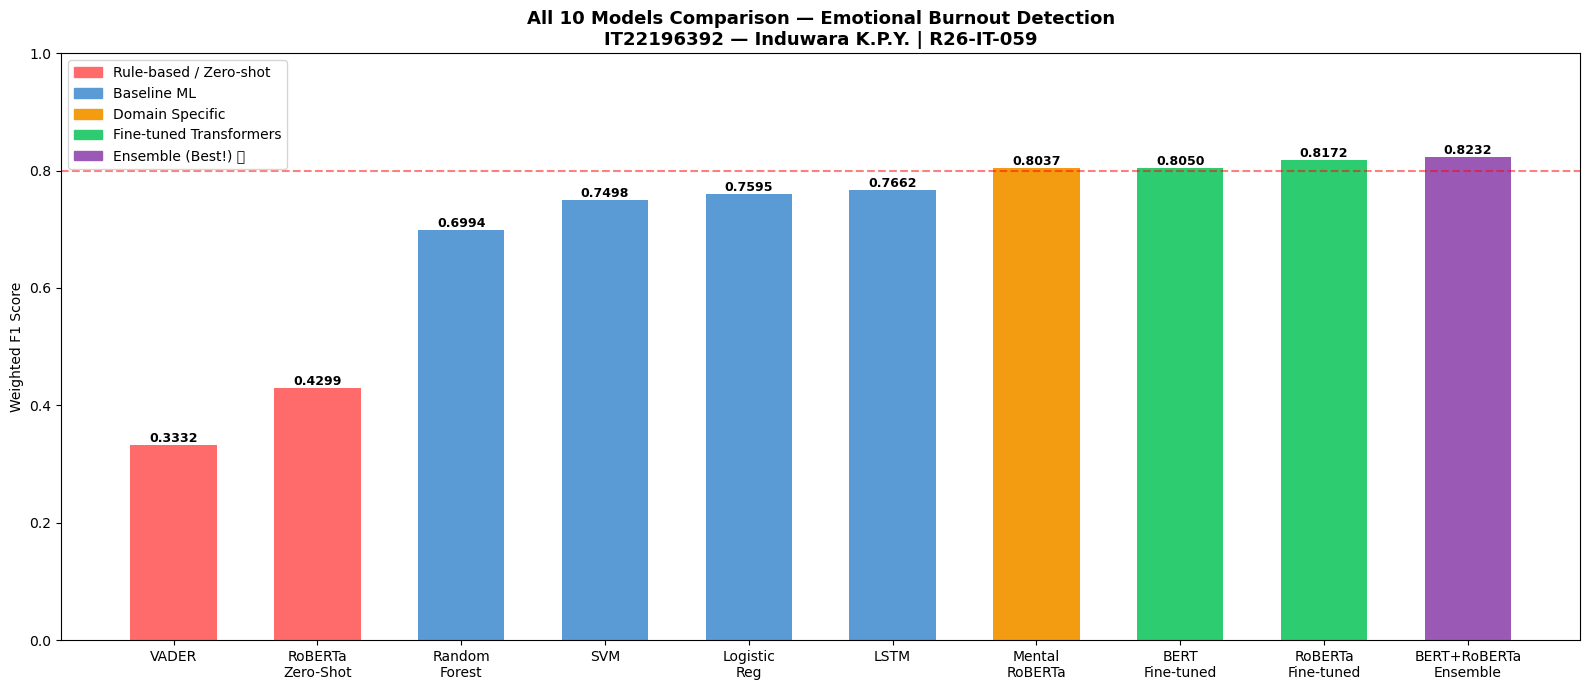

Final comparison chart saved!


: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'VADER', 
    'RoBERTa\nZero-Shot',
    'Random\nForest', 
    'SVM', 
    'Logistic\nReg', 
    'LSTM',
    'Mental\nRoBERTa',
    'BERT\nFine-tuned',
    'RoBERTa\nFine-tuned',
    'BERT+RoBERTa\nEnsemble'
]

f1_scores = [0.3332, 0.4299, 0.6994, 0.7498, 0.7595, 0.7662, 0.8037, 0.8050, 0.8172, 0.8232]

colors = [
    '#ff6b6b', '#ff6b6b',  # red - rule based
    '#5b9bd5', '#5b9bd5', '#5b9bd5', '#5b9bd5',  # blue - baseline ML
    '#f39c12', # orange - domain specific
    '#2ecc71', '#2ecc71',  # green - fine-tuned
    '#9b59b6'  # purple - ensemble (BEST!)
]

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(models, f1_scores, color=colors, width=0.6)

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

ax.set_ylabel('Weighted F1 Score')
ax.set_title('All 10 Models Comparison — Emotional Burnout Detection\nIT22196392 — Induwara K.P.Y. | R26-IT-059', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='80% threshold')

from matplotlib.patches import Patch
legend = [
    Patch(color='#ff6b6b', label='Rule-based / Zero-shot'),
    Patch(color='#5b9bd5', label='Baseline ML'),
    Patch(color='#f39c12', label='Domain Specific'),
    Patch(color='#2ecc71', label='Fine-tuned Transformers'),
    Patch(color='#9b59b6', label='Ensemble (Best!) 🏆')
]
ax.legend(handles=legend, loc='upper left')

plt.tight_layout()
plt.savefig('../results/figures/final_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final comparison chart saved!')

In [ ]:
# ============================================================
# CONFUSION MATRIX — BERT + RoBERTa Ensemble (Best Model)
# Run AFTER the test-set cell (needs true_labels + ensemble_preds)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Order the 7 classes by severity (clean look for the report)
label_order = ['Normal', 'Stress', 'Anxiety', 'Depression',
               'Bipolar', 'Personality disorder', 'Suicidal']

# Build the confusion matrix
cm = confusion_matrix(true_labels, ensemble_preds, labels=label_order)

# Draw it
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_order, yticklabels=label_order,
            cbar_kws={'label': 'Number of samples'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix — BERT + RoBERTa Ensemble (Best Model)\n'
             'R26-IT-059 | IT22196392 | Induwara K.P.Y.',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save to the figures folder
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/confusion_matrix_ensemble.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/confusion_matrix_ensemble.png')